## Model Selection and Bayes Factors

Parameter estimation assumes your model is correct. But what if you want to compare two entirely different physical models?

In Bayesian statistics, we do this by calculating the **Bayes Factor ($K$)**. It is the ratio of the **Evidence** (also called the Marginal Likelihood) of the two models. The Evidence is the denominator of Bayes' Theorem that we previously ignored!

$$K = \frac{P(\text{Data} | \text{H}_1)}{P(\text{Data} | \text{H}_0)}$$

* If $K > 1$, Model 1 is favored.
* If $K > 10$, there is strong evidence for Model 1.
* If $K > 100$, there is decisive evidence for Model 1.

Let's look at a simple tabletop physics example. We are testing a new alloy in a magnetometer.
* **$H_0$ (Null):** The alloy is non-magnetic. The true susceptibility $\chi = 0$. Any non-zero measurement is purely Gaussian instrumental noise.
* **$H_1$ (Paramagnetic):** The alloy is magnetic, meaning $\chi > 0$. We don't know exactly how magnetic it is, so we assign a uniform prior.

In [ ]:
import numpy as np
import scipy.stats as stats
import scipy.integrate as integrate

# --- THE MEASUREMENT ---
# We measure a susceptibility of 2.5 (in units of our instrument's noise, sigma=1)
chi_measured = 2.5
sigma = 1.0

print(f"Measured value: {chi_measured} sigma\n")

# --- MODEL 0: Non-magnetic (chi = 0) ---
# No free parameters. We just evaluate the noise distribution at the measured value.
evidence_M0 = stats.norm.pdf(chi_measured, loc=0, scale=sigma)
print(f"Evidence for Model 0 (Non-magnetic): {evidence_M0:.5f}")

# --- MODEL 1a: Paramagnetic (Reasonable Prior) ---
# We expect the susceptibility to be between 0 and 5.
prior_max_a = 5.0
chi_scan_a = np.linspace(0, prior_max_a, 1000)
prior_a = 1.0 / prior_max_a  # Uniform prior height

# Evidence is the integral of (Likelihood * Prior)
likelihood_a = stats.norm.pdf(chi_measured, loc=chi_scan_a, scale=sigma)
evidence_M1a = integrate.simpson(likelihood_a * prior_a, chi_scan_a)

bayes_factor_a = evidence_M1a / evidence_M0
print(f"Evidence for Model 1a (Prior 0 to 5):  {evidence_M1a:.5f}")
print(f"--> Bayes Factor (M1a vs M0): {bayes_factor_a:.2f}\n")

# --- MODEL 1b: Paramagnetic (Extremely Vague Prior) ---
# We have no idea what to expect, so we guess between 0 and 20.
prior_max_b = 20.0
chi_scan_b = np.linspace(0, prior_max_b, 1000)
prior_b = 1.0 / prior_max_b

likelihood_b = stats.norm.pdf(chi_measured, loc=chi_scan_b, scale=sigma)
evidence_M1b = integrate.simpson(likelihood_b * prior_b, chi_scan_b)

bayes_factor_b = evidence_M1b / evidence_M0
print(f"Evidence for Model 1b (Prior 0 to 20): {evidence_M1b:.5f}")
print(f"--> Bayes Factor (M1b vs M0): {bayes_factor_b:.2f}")

Measured value: 2.5 sigma

Evidence for Model 0 (Non-magnetic): 0.01753
Evidence for Model 1a (Prior 0 to 5):  0.19752
--> Bayes Factor (M1a vs M0): 11.27

Evidence for Model 1b (Prior 0 to 20): 0.04969
--> Bayes Factor (M1b vs M0): 2.83


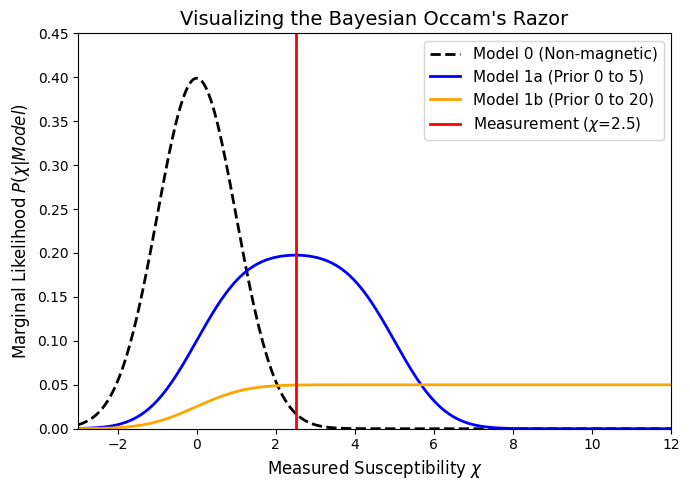

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# X-axis for plotting predictions
chi_axis = np.linspace(-3, 12, 1000)

# 1. Plot Model 0 (Fixed Likelihood at chi=0)
plt.plot(chi_axis, stats.norm.pdf(chi_axis, loc=0, scale=sigma),
         color='black', linestyle='--', linewidth=2, label='Model 0 (Non-magnetic)')

# 2. Plot Model 1a (Averaged Likelihood across Prior 0 to 5)
model_1a_prediction = np.zeros_like(chi_axis)
d_chi_a = chi_scan_a[1] - chi_scan_a[0]
for chi_val in chi_scan_a:
    model_1a_prediction += stats.norm.pdf(chi_axis, loc=chi_val, scale=sigma) * prior_a * d_chi_a

plt.plot(chi_axis, model_1a_prediction,
         color='blue', linewidth=2, label='Model 1a (Prior 0 to 5)')

# 3. Plot Model 1b (Averaged Likelihood across Prior 0 to 20)
model_1b_prediction = np.zeros_like(chi_axis)
d_chi_b = chi_scan_b[1] - chi_scan_b[0]
for chi_val in chi_scan_b:
    model_1b_prediction += stats.norm.pdf(chi_axis, loc=chi_val, scale=sigma) * prior_b * d_chi_b

plt.plot(chi_axis, model_1b_prediction,
         color='orange', linewidth=2, label='Model 1b (Prior 0 to 20)')

# 4. Plot the actual measurement
plt.axvline(chi_measured, color='red', linewidth=2, label=fr'Measurement ($\chi$={chi_measured})')

plt.title("Visualizing the Bayesian Occam's Razor", fontsize=14)
plt.xlabel(r"Measured Susceptibility $\chi$", fontsize=12)
plt.ylabel(r"Marginal Likelihood $P(\chi | Model)$", fontsize=12)
plt.xlim(-3, 12)
plt.ylim(0, 0.45)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### The Bayesian Occam's Razor

When you run the code above, you will notice something that deeply confuses many physicists at first: **The Bayes Factor changes drastically depending on the limits of our prior.**

* With a prior from 0 to 5, $K \approx 11.4$ (Strong evidence for the new magnetic alloy).
* With a prior from 0 to 20, $K \approx 2.8$ (Weak/Inconclusive evidence).

Why does a wider prior lower the evidence for Model 1? Bayesian hypothesis testing naturally includes the concept of **Occam's Razor**.

* If you propose a highly specific model (Prior 0 to 5), your probability density is concentrated. When the data lands in that concentrated region, the model is highly rewarded.
* If you propose a highly vague model (Prior 0 to 20), you are spreading your probability density extremely thin. The model is essentially saying, *"The value could be anything."* The Evidence mathematically penalizes models that are too complex, too vague, or have too many free parameters. A model that can predict *everything* effectively predicts *nothing*. Therefore, to compare two models fairly, you cannot use "infinite" or completely uninformative priors. Your priors must represent actual, physically motivated boundaries predicted by the theory *before* the measurement was made.